# 1. 전처리

In [4]:
import numpy as np
import pandas as pd   
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
import xgboost as xgb
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# -------------------------
# 데이터 로드
# -------------------------
df = pd.read_csv('univ355.csv')

# -------------------------
# 결측치 컬럼 제거
# -------------------------
drop_missing_cols = [
    'why_not_rechoice', 'future_job_desc', 'income_class', 'income_contest',
    'income_perf', 'income_broadcast', 'income_studio', 'income_creator',
    'income_choreo', 'info_dept', 'info_career_center', 'info_online',
    'info_family', 'info_friends', 'info_academy', 'info_self',
    'help_financial', 'help_resume', 'help_career', 'help_social',
    'help_no', 'non_stay_reason', 'total_univ'
]
df = df.drop(columns=drop_missing_cols, errors='ignore')

# -------------------------
# current_area 관련 변수 제거
# -------------------------
current_area_cols = [col for col in df.columns if col.startswith('current_area')]
df = df.drop(columns=current_area_cols, errors='ignore')

# -------------------------
# 오타 수정
# -------------------------
if 'birth_area' in df.columns:
    df['birth_area'] = df['birth_area'].replace({'g': 'gangwon'})  # 'g' -> 'gangwon'

# -------------------------
# 범주형 변수 매핑 및 원-핫 인코딩
# -------------------------
# dance_years 매핑
midpoint_map = {'less2':1, '2to4':2, '4to7':3, '7to10':4, 'over10':5}
if 'dance_years' in df.columns:
    df['dance_years'] = df['dance_years'].map(midpoint_map)

# 원-핫 인코딩
columns_to_encode = [
    'univ_factor', 'major_factor', 'job_region', 'weight_control',
    'birth_area', 'housing_type', 'enter_type',
    'major_detail', 'univ_name', 'univ_area'

]
df = pd.get_dummies(df, columns=columns_to_encode, drop_first=False, dtype=float)

# -------------------------
# 분석 제외 변수 제거
# -------------------------
remove_vars = ["prof_hi", "int_major", "enter_year"]
df = df.drop(columns=remove_vars, errors='ignore')

# -------------------------
# 상관계수 높은 변수 사전 삭제 (전처리 단계)
# -------------------------
high_corr_remove = ['lecture_qual', 'peer_personal', 'enjoy_major', 'prof_chat','peer_study']
df = df.drop(columns=high_corr_remove, errors='ignore')


# -------------------------
# sat 변수 생성 및 이진 분류
# -------------------------
sat_cols = ['univ_proud', 'univ_belong', 'major_proud', 'major_belong']
df['sat'] = df[sat_cols].mean(axis=1)
sat_median = df['sat'].median()
df['sat_group'] = (df['sat'] >= sat_median).astype(int)

# -------------------------
# 설명용 출력
# -------------------------
print("✅ 최종 데이터셋 컬럼 수:", df.shape[1])
print("sat 중위수:", sat_median)
print(df[['sat', 'sat_group']].head())



✅ 최종 데이터셋 컬럼 수: 178
sat 중위수: 4.0
    sat  sat_group
0  4.00          1
1  4.50          1
2  3.00          0
3  3.00          0
4  4.75          1


# 2. 데이터 분할 및 변수선택택

In [5]:
# ======================================
# ✅ 최적화 버전 (6:2:2 분할)
# ElasticNet + RFECV(LR/DT/RF/XGB)
# - 변수선택: X_train 내부에서 수행
# - 폴드별 선택 변수 → 교집합(안정적 변수)
# - CV, Validation, Test 평가 분리
# ======================================

import numpy as np
import pandas as pd
from itertools import combinations
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.feature_selection import RFECV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
import warnings
warnings.filterwarnings("ignore")

# -------------------------
# 설정
# -------------------------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# -------------------------
# 데이터 존재 확인
# -------------------------
try:
    df
except NameError:
    raise RuntimeError("데이터프레임 df가 존재하지 않습니다. 먼저 전처리 셀을 실행하세요.")

# -------------------------
# 타깃/설명변수 설정
# -------------------------
target_col = 'sat_group'
drop_cols = ['id','univ_proud','univ_belong','major_proud','major_belong','sat','sat_group']
X = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')
y = df[target_col].copy()

# -------------------------
# 학습/검증/테스트 분할 (6:2:2)
# -------------------------
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, stratify=y_train_val, random_state=42
)
print(f"Train: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")

# -------------------------
# CV 설정
# -------------------------
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"accuracy": "accuracy", "f1": "f1", "roc_auc": "roc_auc"}

# -------------------------
# RFECV 파이프라인 생성 함수
# -------------------------
def make_rfecv_pipeline(base_estimator, final_estimator=None):
    """RFECV 기반 파이프라인 생성"""
    if final_estimator is None:
        final_estimator = base_estimator
    rfecv = RFECV(
        estimator=base_estimator,
        step=1,
        cv=inner_cv,
        scoring='f1',
        min_features_to_select=max(1, int(0.05 * X_train.shape[1])),
        n_jobs=1,
        verbose=0
    )
    # LogisticRegression일 때만 스케일러 추가
    if isinstance(base_estimator, LogisticRegression):
        return Pipeline([("scaler", StandardScaler()),
                         ("feature_selection", rfecv),
                         ("clf", final_estimator)])
    else:
        return Pipeline([("feature_selection", rfecv),
                         ("clf", final_estimator)])

# -------------------------
# 모델 정의
# -------------------------
models = {
    "ElasticNet": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegressionCV(
            Cs=10, cv=inner_cv, penalty="elasticnet", solver="saga",
            l1_ratios=[.1,.3,.5,.7,.9], scoring="f1",
            max_iter=5000, random_state=RANDOM_STATE, n_jobs=-1
        ))
    ]),
    "RFECV_LR": make_rfecv_pipeline(LogisticRegression(max_iter=1000, solver='liblinear', random_state=RANDOM_STATE)),
    "RFECV_DT": make_rfecv_pipeline(DecisionTreeClassifier(random_state=RANDOM_STATE)),
    "RFECV_RF": make_rfecv_pipeline(RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)),
    "RFECV_XGB": make_rfecv_pipeline(XGBClassifier(n_estimators=200, random_state=RANDOM_STATE,
                                                   use_label_encoder=False, eval_metric='logloss', n_jobs=-1))
}

# -------------------------
# 폴드별 선택 변수 추출
# -------------------------
def extract_fold_selected(pipe_name):
    fold_sets = []
    for tr_idx, val_idx in outer_cv.split(X_train, y_train):
        X_tr, y_tr = X_train.iloc[tr_idx], y_train.iloc[tr_idx]

        if pipe_name == "ElasticNet":
            enet_fold = LogisticRegressionCV(
                Cs=10, cv=inner_cv, penalty="elasticnet", solver="saga",
                l1_ratios=[.1,.3,.5,.7,.9], scoring="f1",
                max_iter=5000, random_state=RANDOM_STATE, n_jobs=-1
            )
            enet_fold.fit(X_tr, y_tr)
            sel = set(X_tr.columns[enet_fold.coef_.ravel() != 0])
        else:
            base_map = {
                "RFECV_LR": LogisticRegression(max_iter=1000, solver='liblinear', random_state=RANDOM_STATE),
                "RFECV_DT": DecisionTreeClassifier(random_state=RANDOM_STATE),
                "RFECV_RF": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
                "RFECV_XGB": XGBClassifier(n_estimators=200, random_state=RANDOM_STATE,
                                           eval_metric='logloss', n_jobs=-1)
            }
            rfecv_fold = RFECV(
                estimator=base_map[pipe_name], step=1, cv=inner_cv, scoring='f1',
                min_features_to_select=max(1, int(0.05 * X_train.shape[1])),
                n_jobs=1
            )
            rfecv_fold.fit(X_tr, y_tr)
            sel = set(X_tr.columns[rfecv_fold.support_])
        fold_sets.append(sel)
    return fold_sets

selected_per_model = {name: extract_fold_selected(name) for name in models.keys()}

# -------------------------
# Jaccard 안정성 지수
# -------------------------
def mean_pairwise_jaccard(list_of_sets):
    if len(list_of_sets) < 2: return np.nan
    scores = []
    for i, j in combinations(range(len(list_of_sets)), 2):
        a, b = list_of_sets[i], list_of_sets[j]
        scores.append(1.0 if len(a | b) == 0 else len(a & b) / len(a | b))
    return np.mean(scores)

# -------------------------
# CV & Validation & Test 평가
# -------------------------
results = []
for name, pipe in models.items():
    print(f"\n===== 평가 중: {name} =====")

    # CV 결과 (훈련 데이터 내)
    cv_res = cross_validate(pipe, X_train, y_train, cv=outer_cv, scoring=scoring,
                            n_jobs=-1, error_score=np.nan)
    cv_mean = {m: np.nanmean(cv_res[f"test_{m}"]) for m in scoring.keys()}
    cv_std = {m: np.nanstd(cv_res[f"test_{m}"]) for m in scoring.keys()}

    fitted_pipe = pipe.fit(X_train, y_train)

    # Validation 성능
    y_val_pred = fitted_pipe.predict(X_val)
    try:
        y_val_score = fitted_pipe.predict_proba(X_val)[:, 1]
    except:
        try: y_val_score = fitted_pipe.decision_function(X_val)
        except: y_val_score = None

    val_metrics = {
        "accuracy": accuracy_score(y_val, y_val_pred),
        "f1": f1_score(y_val, y_val_pred),
        "precision": precision_score(y_val, y_val_pred, zero_division=0),
        "recall": recall_score(y_val, y_val_pred),
        "roc_auc": roc_auc_score(y_val, y_val_score) if y_val_score is not None else np.nan
    }

    # Test 성능
    y_pred = fitted_pipe.predict(X_test)
    try:
        y_score = fitted_pipe.predict_proba(X_test)[:,1]
    except:
        try: y_score = fitted_pipe.decision_function(X_test)
        except: y_score = None

    holdout_metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_score) if y_score is not None else np.nan
    }

    fold_sets = selected_per_model[name]
    stable_vars = set.intersection(*fold_sets) if fold_sets else set()
    jacc = mean_pairwise_jaccard(fold_sets)

    # 최종 선택 변수
    final_selected = []
    if "feature_selection" in fitted_pipe.named_steps:
        try:
            final_selected = list(X_train.columns[fitted_pipe.named_steps['feature_selection'].support_])
        except:
            final_selected = []
    elif name == "ElasticNet":
        try:
            final_selected = list(X_train.columns[fitted_pipe.named_steps['clf'].coef_.ravel()!=0])
        except:
            final_selected = []

    results.append({
        "model": name,
        "cv_mean": cv_mean,
        "cv_std": cv_std,
        "val": val_metrics,
        "holdout": holdout_metrics,
        "jaccard": jacc,
        "stable_vars": sorted(list(stable_vars)),
        "final_selected": sorted(final_selected)
    })

# -------------------------
# 결과 요약
# -------------------------
summary_rows = []
for r in results:
    # CV metrics mean & std
    cv_metrics = {}
    for m in r["cv_mean"].keys():
        cv_metrics[f"CV_{m}_mean"] = r["cv_mean"][m]
        cv_metrics[f"CV_{m}_std"] = r["cv_std"][m]
    
    # Validation metrics
    val_metrics = {f"Val_{k}": v for k, v in r["val"].items()}
    
    # Holdout(Test) metrics
    test_metrics = {f"Test_{k}": v for k, v in r["holdout"].items()}
    
    summary_rows.append({
        "model": r["model"],
        "n_stable_vars": len(r["stable_vars"]),
        "stable_vars": ", ".join(r["stable_vars"]),
        "Jaccard": r["jaccard"],
        **cv_metrics,
        **val_metrics,
        **test_metrics
    })

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values(by="CV_f1_mean", ascending=False)
display(summary_df)


summary_df = pd.DataFrame(summary_rows).sort_values(by="CV_f1_mean", ascending=False)
print("\n\n=== 요약 표 ===")
display(summary_df)

for r in results:
    print(f"\n--- {r['model']} ---")
    print(f"폴드 교집합(안정적) 변수 수: {len(r['stable_vars'])}")
    print("안정적 변수:" + (", ".join(r['stable_vars']) if r['stable_vars'] else " 없음"))
    print(f"최종 선택 변수 수: {len(r['final_selected'])}")
    print("최종 선택 변수:" + (", ".join(r['final_selected']) if r['final_selected'] else " 없음"))


Train: (213, 171), Validation: (71, 171), Test: (71, 171)

===== 평가 중: ElasticNet =====

===== 평가 중: RFECV_LR =====

===== 평가 중: RFECV_DT =====

===== 평가 중: RFECV_RF =====

===== 평가 중: RFECV_XGB =====


,model,n_stable_vars,stable_vars,Jaccard,CV_accuracy_mean,CV_accuracy_std,CV_f1_mean,CV_f1_std,CV_roc_auc_mean,CV_roc_auc_std,Val_accuracy,Val_f1,Val_precision,Val_recall,Val_roc_auc,Test_accuracy,Test_f1,Test_precision,Test_recall,Test_roc_auc
3,RFECV_RF,36,"ask_q, car_spt, change_career, change_major, c...",0.614355,0.798671,0.062259,0.838695,0.057563,0.875107,0.056229,0.788732,0.831461,0.804348,0.860465,0.916944,0.830986,0.863636,0.844444,0.883721,0.875000
0,ElasticNet,9,"course_variety, peer_advice, peer_event, prof_...",0.377975,0.774972,0.061008,0.823886,0.057414,0.877307,0.037779,0.816901,0.853933,0.826087,0.883721,0.893688,0.802817,0.837209,0.837209,0.837209,0.857143
4,RFECV_XGB,6,"course_variety, peer_event, prof_access, prof_...",0.329157,0.779402,0.056294,0.818751,0.052435,0.841508,0.056854,0.774648,0.818182,0.800000,0.837209,0.861296,0.774648,0.800000,0.864865,0.744186,0.887043
1,RFECV_LR,16,"change_major, edu_doubt, exp_concours, exp_vid...",0.382284,0.751163,0.048534,0.797266,0.044431,0.822189,0.033740,0.774648,0.804878,0.846154,0.767442,0.849668,0.704225,0.746988,0.775000,0.720930,0.794020
2,RFECV_DT,34,"change_career, change_major, drink_freq, drop_...",0.603635,0.694906,0.056522,0.741617,0.065696,0.680516,0.045279,0.690141,0.750000,0.733333,0.767442,0.669435,0.774648,0.804878,0.846154,0.767442,0.776578




=== 요약 표 ===


,model,n_stable_vars,stable_vars,Jaccard,CV_accuracy_mean,CV_accuracy_std,CV_f1_mean,CV_f1_std,CV_roc_auc_mean,CV_roc_auc_std,Val_accuracy,Val_f1,Val_precision,Val_recall,Val_roc_auc,Test_accuracy,Test_f1,Test_precision,Test_recall,Test_roc_auc
3,RFECV_RF,36,"ask_q, car_spt, change_career, change_major, c...",0.614355,0.798671,0.062259,0.838695,0.057563,0.875107,0.056229,0.788732,0.831461,0.804348,0.860465,0.916944,0.830986,0.863636,0.844444,0.883721,0.875000
0,ElasticNet,9,"course_variety, peer_advice, peer_event, prof_...",0.377975,0.774972,0.061008,0.823886,0.057414,0.877307,0.037779,0.816901,0.853933,0.826087,0.883721,0.893688,0.802817,0.837209,0.837209,0.837209,0.857143
4,RFECV_XGB,6,"course_variety, peer_event, prof_access, prof_...",0.329157,0.779402,0.056294,0.818751,0.052435,0.841508,0.056854,0.774648,0.818182,0.800000,0.837209,0.861296,0.774648,0.800000,0.864865,0.744186,0.887043
1,RFECV_LR,16,"change_major, edu_doubt, exp_concours, exp_vid...",0.382284,0.751163,0.048534,0.797266,0.044431,0.822189,0.033740,0.774648,0.804878,0.846154,0.767442,0.849668,0.704225,0.746988,0.775000,0.720930,0.794020
2,RFECV_DT,34,"change_career, change_major, drink_freq, drop_...",0.603635,0.694906,0.056522,0.741617,0.065696,0.680516,0.045279,0.690141,0.750000,0.733333,0.767442,0.669435,0.774648,0.804878,0.846154,0.767442,0.776578



--- ElasticNet ---
폴드 교집합(안정적) 변수 수: 9
안정적 변수:course_variety, peer_advice, peer_event, prof_access, prof_passion, prof_personal, student_interact, theory_cls, time_eff
최종 선택 변수 수: 21
최종 선택 변수:change_major, course_variety, exp_concours, exp_video, move_univ, peer_advice, peer_event, peer_external, prof_access, prof_career, prof_passion, prof_personal, student_interact, students_diligent, theory_cls, time_eff, try_hard, univ_factor_prefer_prof, univ_name_jau, univ_name_pku, weight_control_keep_weight

--- RFECV_LR ---
폴드 교집합(안정적) 변수 수: 16
안정적 변수:change_major, edu_doubt, exp_concours, exp_video, major_detail_streetdance, peer_advice, peer_event, prof_passion, theory_cls, time_eff, univ_course_year, univ_factor_edu_structure, univ_factor_prefer_prof, univ_name_swu, weight_control_keep_weight, weight_control_no_weight
최종 선택 변수 수: 120
최종 선택 변수:abroad_practice, ask_q, birth_area_chungcheong, birth_area_gangwon, birth_area_honam, birth_area_seoul, birth_area_yeongnam, burnout, car_spt, career

# 3. RFECV_RF, ENET 선택변수 기반 모델링 

In [6]:
# ======================================
# ✅ 최종 모델링 (6:2:2 분할, RFECV_RF vs ElasticNet 변수)
# LogisticRegression / DecisionTree / RandomForest / XGBoost
# - 누수 방지: 변수는 미리 확정된 상태, 학습 데이터에서만 모델 훈련
# ======================================

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
import warnings
warnings.filterwarnings("ignore")

# -------------------------
# 설정
# -------------------------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# -------------------------
# 변수 세트 정의
# -------------------------
rfecv_rf_vars = [
    'ask_q','car_spt','change_career','change_major','cont_major','course_variety',
    'drink_freq','fit_major','get_fdbk','housing_neighbor','housing_transit','intern_abroad',
    'lecture_fac','peer_advice','peer_career','peer_class','peer_event','peer_external',
    'prac_cls','prof_access','prof_career','prof_effort','prof_event','prof_grade','prof_other_talk',
    'prof_passion','prof_personal','real_appl','student_interact','students_diligent','study_hard',
    'support_fac','theory_cls','time_eff','transport','work_fee'
]

elasticnet_vars = [
    'course_variety','peer_advice','peer_event','prof_access','prof_passion',
    'prof_personal','student_interact','theory_cls','time_eff'
]

# -------------------------
# 데이터 준비
# -------------------------
target_col = 'sat_group'
X_rfecv = df[rfecv_rf_vars].copy()
X_enet = df[elasticnet_vars].copy()
y = df[target_col].copy()

# -------------------------
# 데이터 분할 (6:2:2)
# -------------------------
def split_data(X, y):
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, test_size=0.25, stratify=y_train_val, random_state=RANDOM_STATE
    )
    return X_train, X_val, X_test, y_train, y_val, y_test

X_train_rf, X_val_rf, X_test_rf, y_train_rf, y_val_rf, y_test_rf = split_data(X_rfecv, y)
X_train_en, X_val_en, X_test_en, y_train_en, y_val_en, y_test_en = split_data(X_enet, y)

# -------------------------
# 모델 정의
# -------------------------
def get_models():
    return {
        "LogisticRegression": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=2000, solver='liblinear', random_state=RANDOM_STATE))
        ]),
        "DecisionTree": DecisionTreeClassifier(random_state=RANDOM_STATE),
        "RandomForest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
        "XGBoost": XGBClassifier(n_estimators=300, random_state=RANDOM_STATE,
                                 eval_metric='logloss', use_label_encoder=False, n_jobs=-1)
    }

# ==============================
# 최종 평가 함수 (CV/Val/Test, 다양한 성능 지표)
# ==============================
def evaluate_models_verbose(X_train, X_val, X_test, y_train, y_val, y_test, models_dict):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scoring = {"accuracy": "accuracy", "f1": "f1", "precision": "precision", "recall": "recall", "roc_auc": "roc_auc"}
    results = []
    
    for name, model in models_dict.items():
        print(f"\n===== {name} 평가 중 =====")
        
        # 1️⃣ CV 평가
        cv_res = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
        cv_mean = {f"CV_{k}_mean": np.mean(cv_res[f"test_{k}"]) for k in scoring.keys()}
        cv_std = {f"CV_{k}_std": np.std(cv_res[f"test_{k}"]) for k in scoring.keys()}
        
        # 2️⃣ 모델 학습
        fitted = model.fit(X_train, y_train)
        
        # 3️⃣ Validation 평가
        y_val_pred = fitted.predict(X_val)
        try: y_val_score = fitted.predict_proba(X_val)[:,1]
        except: y_val_score = None
        val_metrics = {f"Val_{k}": v for k,v in {
            "accuracy": accuracy_score(y_val, y_val_pred),
            "f1": f1_score(y_val, y_val_pred),
            "precision": precision_score(y_val, y_val_pred, zero_division=0),
            "recall": recall_score(y_val, y_val_pred),
            "roc_auc": roc_auc_score(y_val, y_val_score) if y_val_score is not None else np.nan
        }.items()}
        
        # 4️⃣ Test 평가
        y_test_pred = fitted.predict(X_test)
        try: y_test_score = fitted.predict_proba(X_test)[:,1]
        except: y_test_score = None
        test_metrics = {f"Test_{k}": v for k,v in {
            "accuracy": accuracy_score(y_test, y_test_pred),
            "f1": f1_score(y_test, y_test_pred),
            "precision": precision_score(y_test, y_test_pred, zero_division=0),
            "recall": recall_score(y_test, y_test_pred),
            "roc_auc": roc_auc_score(y_test, y_test_score) if y_test_score is not None else np.nan
        }.items()}
        
        # 5️⃣ 결과 합치기
        results.append({
            "model": name,
            **cv_mean,
            **cv_std,
            **val_metrics,
            **test_metrics
        })
        
        # 6️⃣ 모델별 세부 print
        print("CV 평균 성능:", {k:v for k,v in cv_mean.items()})
        print("CV 표준편차:", {k:v for k,v in cv_std.items()})
        print("Validation 성능:", val_metrics)
        print("Test 성능:", test_metrics)
    
    # 7️⃣ 최종 DataFrame
    summary_df = pd.DataFrame(results).sort_values(by="CV_f1_mean", ascending=False)
    return summary_df

# ==============================
# RFECV_RF 변수 모델링
# ==============================
print("\n\n=== RFECV_RF 변수 모델링 ===")
models_rf = get_models()
summary_rf = evaluate_models_verbose(X_train_rf, X_val_rf, X_test_rf, y_train_rf, y_val_rf, y_test_rf, models_rf)
display(summary_rf)

# ==============================
# ElasticNet 변수 모델링
# ==============================
print("\n\n=== ElasticNet 변수 모델링 ===")
models_en = get_models()
summary_en = evaluate_models_verbose(X_train_en, X_val_en, X_test_en, y_train_en, y_val_en, y_test_en, models_en)
display(summary_en)




=== RFECV_RF 변수 모델링 ===

===== LogisticRegression 평가 중 =====
CV 평균 성능: {'CV_accuracy_mean': 0.8073089700996677, 'CV_f1_mean': 0.840965234628739, 'CV_precision_mean': 0.8342014019433375, 'CV_recall_mean': 0.852, 'CV_roc_auc_mean': 0.8807307692307692}
CV 표준편차: {'CV_accuracy_std': 0.040999962176677424, 'CV_f1_std': 0.03844304924627337, 'CV_precision_std': 0.020533749188809538, 'CV_recall_std': 0.08049785913577942, 'CV_roc_auc_std': 0.048327420659926915}
Validation 성능: {'Val_accuracy': 0.8450704225352113, 'Val_f1': 0.8735632183908046, 'Val_precision': 0.8636363636363636, 'Val_recall': 0.8837209302325582, 'Val_roc_auc': 0.8862126245847176}
Test 성능: {'Test_accuracy': 0.7183098591549296, 'Test_f1': 0.7560975609756098, 'Test_precision': 0.7948717948717948, 'Test_recall': 0.7209302325581395, 'Test_roc_auc': 0.8430232558139534}

===== DecisionTree 평가 중 =====
CV 평균 성능: {'CV_accuracy_mean': 0.6481727574750831, 'CV_f1_mean': 0.6965013215317475, 'CV_precision_mean': 0.7185381125226862, 'CV_recall_

,model,CV_accuracy_mean,CV_f1_mean,CV_precision_mean,CV_recall_mean,CV_roc_auc_mean,CV_accuracy_std,CV_f1_std,CV_precision_std,CV_recall_std,...,Val_accuracy,Val_f1,Val_precision,Val_recall,Val_roc_auc,Test_accuracy,Test_f1,Test_precision,Test_recall,Test_roc_auc
2,RandomForest,0.802990,0.841373,0.819197,0.868000,0.877779,0.033892,0.031376,0.029431,0.062994,...,0.802817,0.844444,0.808511,0.883721,0.899917,0.816901,0.847059,0.857143,0.837209,0.896179
0,LogisticRegression,0.807309,0.840965,0.834201,0.852000,0.880731,0.041000,0.038443,0.020534,0.080498,...,0.845070,0.873563,0.863636,0.883721,0.886213,0.718310,0.756098,0.794872,0.720930,0.843023
3,XGBoost,0.784385,0.823689,0.815828,0.836923,0.858038,0.073282,0.060342,0.066733,0.089628,...,0.774648,0.818182,0.800000,0.837209,0.852990,0.816901,0.843373,0.875000,0.813953,0.887043
1,DecisionTree,0.648173,0.696501,0.718538,0.689231,0.636527,0.069160,0.086680,0.055331,0.141555,...,0.732394,0.771084,0.800000,0.744186,0.729236,0.774648,0.809524,0.829268,0.790698,0.770349




=== ElasticNet 변수 모델링 ===

===== LogisticRegression 평가 중 =====
CV 평균 성능: {'CV_accuracy_mean': 0.8264673311184939, 'CV_f1_mean': 0.8609958210623198, 'CV_precision_mean': 0.84477993182341, 'CV_recall_mean': 0.8833846153846154, 'CV_roc_auc_mean': 0.9055825791855204}
CV 표준편차: {'CV_accuracy_std': 0.022537011467402, 'CV_f1_std': 0.010139811140752646, 'CV_precision_std': 0.053104107310030325, 'CV_recall_std': 0.04331144948861369, 'CV_roc_auc_std': 0.025804873371748742}
Validation 성능: {'Val_accuracy': 0.8028169014084507, 'Val_f1': 0.8333333333333334, 'Val_precision': 0.8536585365853658, 'Val_recall': 0.813953488372093, 'Val_roc_auc': 0.8754152823920266}
Test 성능: {'Test_accuracy': 0.7464788732394366, 'Test_f1': 0.7804878048780488, 'Test_precision': 0.8205128205128205, 'Test_recall': 0.7441860465116279, 'Test_roc_auc': 0.856312292358804}

===== DecisionTree 평가 중 =====
CV 평균 성능: {'CV_accuracy_mean': 0.6951273532668881, 'CV_f1_mean': 0.7416975181681064, 'CV_precision_mean': 0.7619796174787099, '

,model,CV_accuracy_mean,CV_f1_mean,CV_precision_mean,CV_recall_mean,CV_roc_auc_mean,CV_accuracy_std,CV_f1_std,CV_precision_std,CV_recall_std,...,Val_accuracy,Val_f1,Val_precision,Val_recall,Val_roc_auc,Test_accuracy,Test_f1,Test_precision,Test_recall,Test_roc_auc
0,LogisticRegression,0.826467,0.860996,0.844780,0.883385,0.905583,0.022537,0.010140,0.053104,0.043311,...,0.802817,0.833333,0.853659,0.813953,0.875415,0.746479,0.780488,0.820513,0.744186,0.856312
2,RandomForest,0.769767,0.808574,0.814028,0.805846,0.866064,0.032545,0.029231,0.027776,0.055805,...,0.774648,0.818182,0.800000,0.837209,0.861711,0.760563,0.795181,0.825000,0.767442,0.882060
3,XGBoost,0.737431,0.781140,0.793151,0.775385,0.841891,0.052560,0.044212,0.061512,0.069894,...,0.802817,0.837209,0.837209,0.837209,0.885382,0.774648,0.804878,0.846154,0.767442,0.868771
1,DecisionTree,0.695127,0.741698,0.761980,0.727692,0.685253,0.047716,0.046089,0.051092,0.069928,...,0.718310,0.761905,0.780488,0.744186,0.707641,0.830986,0.846154,0.942857,0.767442,0.856312


# 4. 복합지표 

In [9]:
# ======================================
# ✅ 복합지표 기준 모델 비교
# ======================================

summary_rf["variable_set"] = "RFECV_RF"
summary_en["variable_set"] = "ElasticNet"

# 변수 수 추가
summary_rf["n_features"] = len(rfecv_rf_vars)
summary_en["n_features"] = len(elasticnet_vars)

combined_results_df = pd.concat([summary_rf, summary_en], ignore_index=True)

# -------------------------
# 복합지표 계산
# -------------------------
# 1) 모델 평균 성능(perf_mean)
combined_results_df["perf_mean"] = combined_results_df[
    ["Test_f1", "Test_roc_auc", "Test_accuracy"]
].mean(axis=1)

# 2) 과적합 수치(overfit_gap)
combined_results_df["overfit_gap"] = (
    abs(combined_results_df["CV_f1_mean"] - combined_results_df["Test_f1"]) +
    abs(combined_results_df["CV_f1_mean"] - combined_results_df["Test_roc_auc"]) +
    abs(combined_results_df["CV_f1_mean"] - combined_results_df["Test_accuracy"])
) / 3

# 3) 변수 복잡도 패널티
total_features = max(len(rfecv_rf_vars), len(elasticnet_vars))
combined_results_df["var_penalty"] = combined_results_df["n_features"] / total_features

# 4) 최종 composite score
combined_results_df["composite_score"] = (
    combined_results_df["perf_mean"]
    - 0.5 * combined_results_df["overfit_gap"]
    - 0.2 * combined_results_df["var_penalty"]
)

# -------------------------
# 최종 정렬 출력
# -------------------------
combined_results_df = combined_results_df.sort_values(by="composite_score", ascending=False)

print("\n=== 복합지표 기준 최적 모델 Top 10 ===")
display(combined_results_df.head(10))




=== 복합지표 기준 최적 모델 Top 10 ===


,model,CV_accuracy_mean,CV_f1_mean,CV_precision_mean,CV_recall_mean,CV_roc_auc_mean,CV_accuracy_std,CV_f1_std,CV_precision_std,CV_recall_std,...,Test_f1,Test_precision,Test_recall,Test_roc_auc,variable_set,n_features,perf_mean,overfit_gap,var_penalty,composite_score
6,XGBoost,0.737431,0.781140,0.793151,0.775385,0.841891,0.052560,0.044212,0.061512,0.069894,...,0.804878,0.846154,0.767442,0.868771,ElasticNet,9,0.816099,0.039287,0.25,0.746455
7,DecisionTree,0.695127,0.741698,0.761980,0.727692,0.685253,0.047716,0.046089,0.051092,0.069928,...,0.846154,0.942857,0.767442,0.856312,ElasticNet,9,0.844484,0.102786,0.25,0.743091
5,RandomForest,0.769767,0.808574,0.814028,0.805846,0.866064,0.032545,0.029231,0.027776,0.055805,...,0.795181,0.825000,0.767442,0.882060,ElasticNet,9,0.812601,0.044963,0.25,0.740120
4,LogisticRegression,0.826467,0.860996,0.844780,0.883385,0.905583,0.022537,0.010140,0.053104,0.043311,...,0.780488,0.820513,0.744186,0.856312,ElasticNet,9,0.794426,0.066569,0.25,0.711142
0,RandomForest,0.802990,0.841373,0.819197,0.868000,0.877779,0.033892,0.031376,0.029431,0.062994,...,0.847059,0.857143,0.837209,0.896179,RFECV_RF,36,0.853380,0.028321,1.00,0.639219
2,XGBoost,0.784385,0.823689,0.815828,0.836923,0.858038,0.073282,0.060342,0.066733,0.089628,...,0.843373,0.875000,0.813953,0.887043,RFECV_RF,36,0.849106,0.029942,1.00,0.634135
3,DecisionTree,0.648173,0.696501,0.718538,0.689231,0.636527,0.069160,0.086680,0.055331,0.141555,...,0.809524,0.829268,0.790698,0.770349,RFECV_RF,36,0.784840,0.088339,1.00,0.540671
1,LogisticRegression,0.807309,0.840965,0.834201,0.852000,0.880731,0.041000,0.038443,0.020534,0.080498,...,0.756098,0.794872,0.720930,0.843023,RFECV_RF,36,0.772477,0.069860,1.00,0.537547


# 5. RFECV_RF+RF, ENET+XGB 상세성능관찰 



===== ENet_XGB =====
Confusion Matrix:


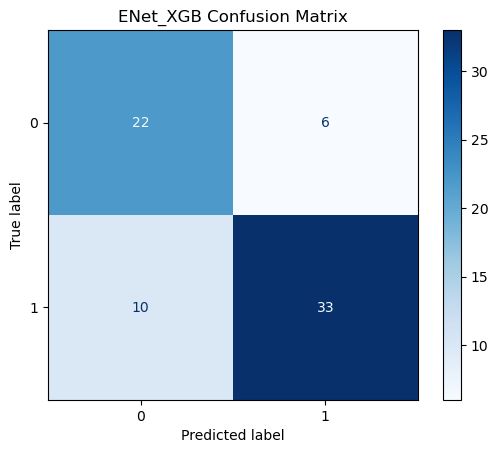

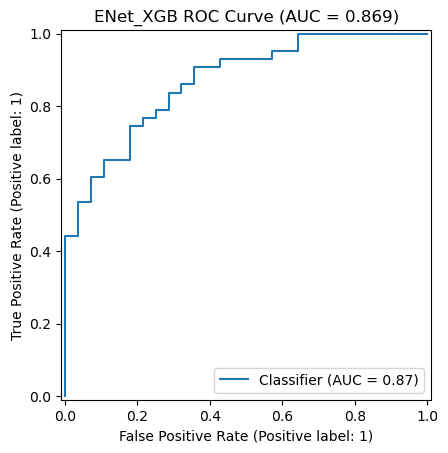


🔍 ENet_XGB SHAP 계산 중...

🔹 ENet_XGB SHAP 중요도 상위 40개


,feature,mean_abs_shap
6,student_interact,1.349631
4,prof_passion,1.173097
3,prof_access,1.102445
0,course_variety,1.021396
8,time_eff,0.906999
2,peer_event,0.791792
7,theory_cls,0.720760
5,prof_personal,0.702201
1,peer_advice,0.469476


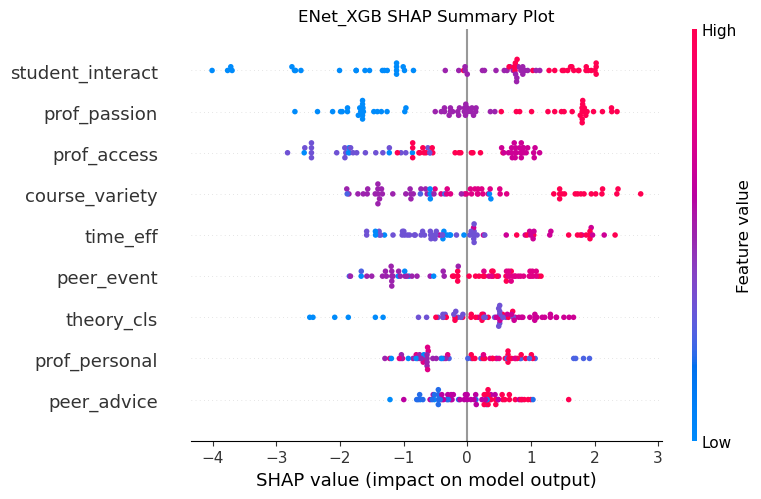



===== RFECV_RF =====
Confusion Matrix:


<Figure size 800x600 with 0 Axes>

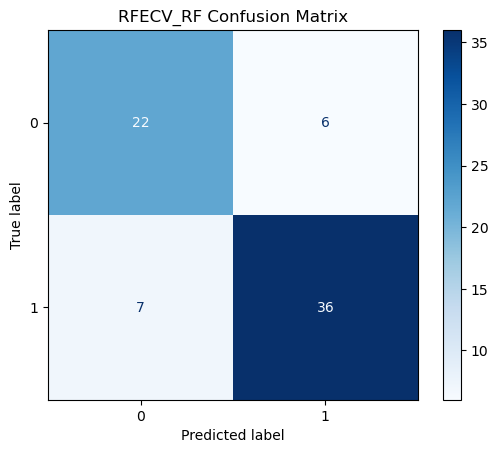

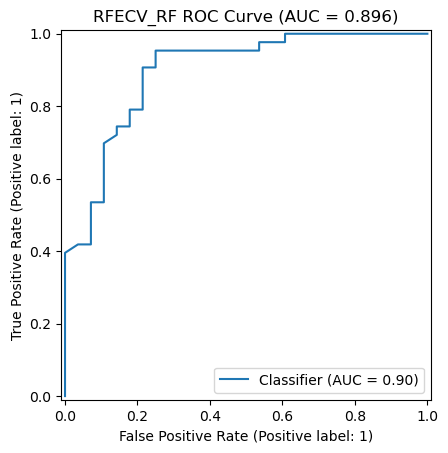


🔍 RFECV_RF SHAP 계산 중...

🔹 RFECV_RF SHAP 중요도 상위 40개


,feature,mean_abs_shap
25,prof_passion,0.061069
28,student_interact,0.054217
5,course_variety,0.042435
19,prof_access,0.040874
16,peer_event,0.034920
1,car_spt,0.025105
29,students_diligent,0.024463
32,theory_cls,0.017294
13,peer_advice,0.015980
26,prof_personal,0.015845


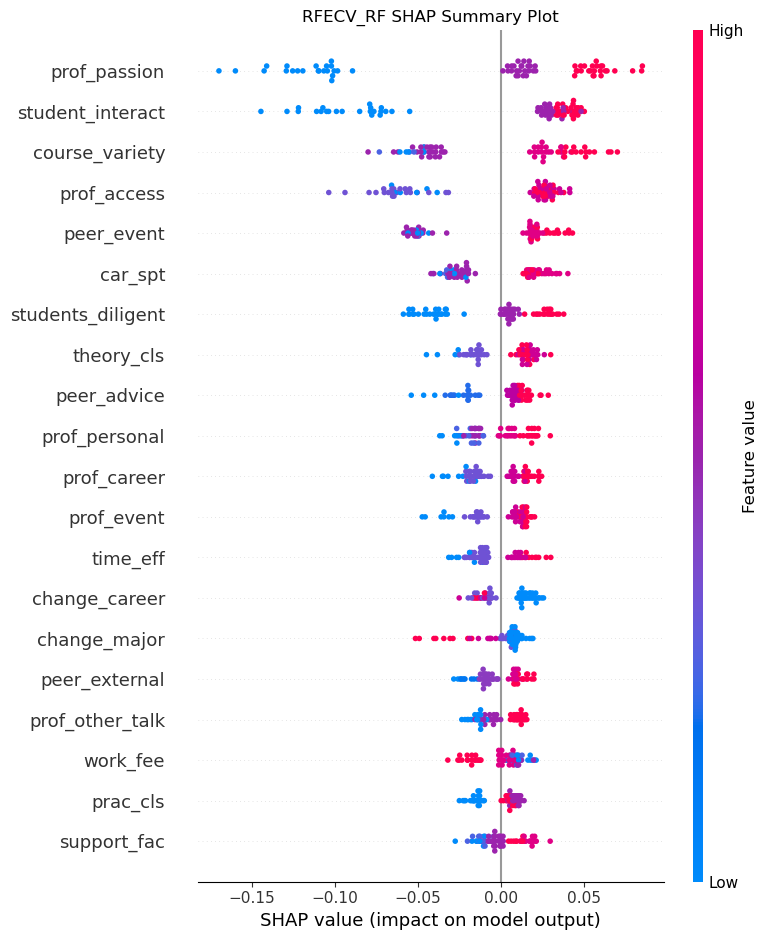

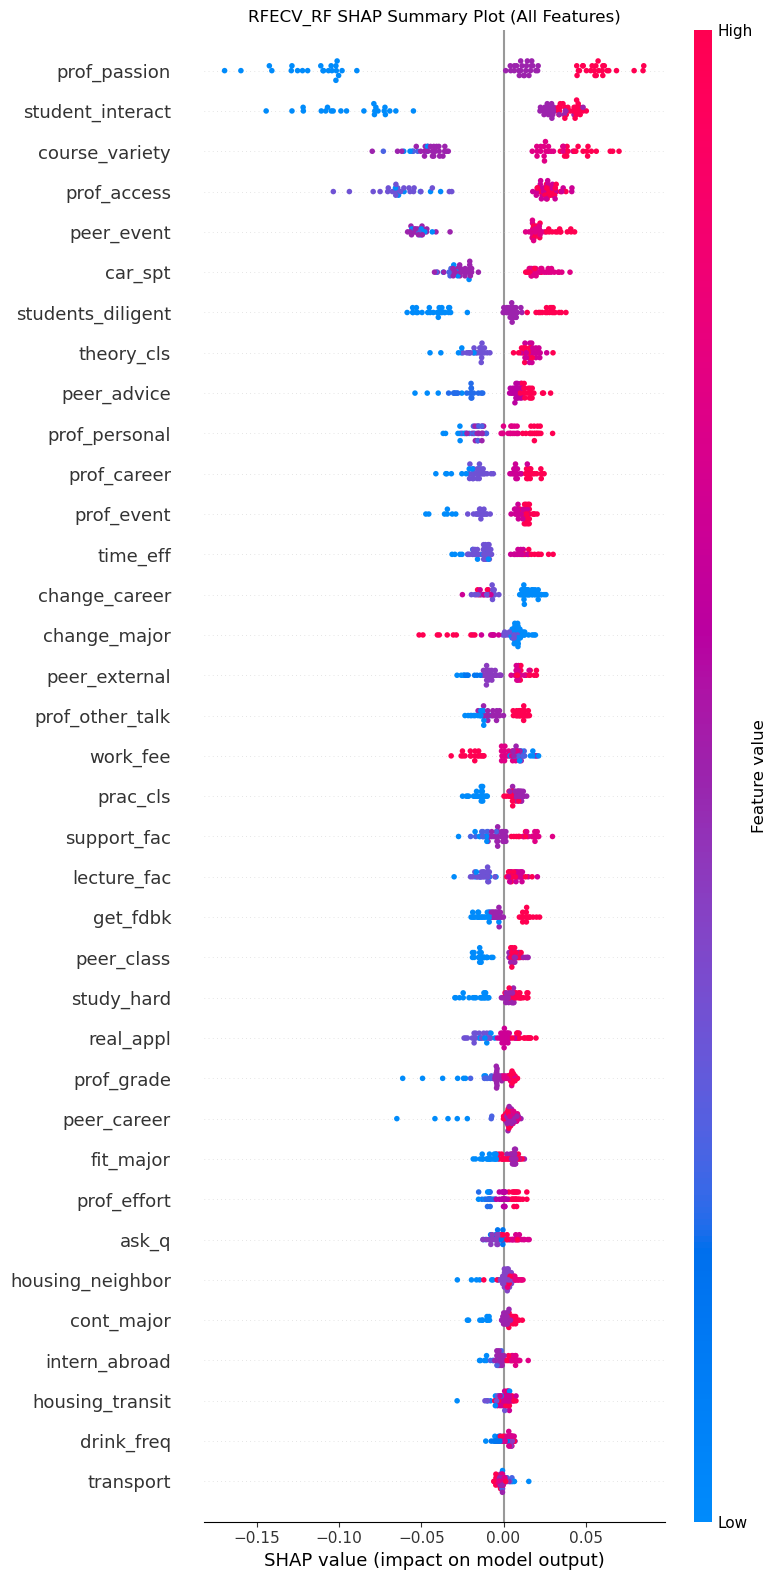

In [15]:
# ======================================
# ✅ 모델 집중 관찰: ENet_XGB / RFECV_RF
# ======================================

import matplotlib.pyplot as plt
import shap
import pandas as pd
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

RANDOM_STATE = 42

# -------------------------
# 1) 집중 관찰할 모델 정의
# -------------------------
focus_models = {
    "ENet_XGB": {
        "model": XGBClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            eval_metric='logloss',
            use_label_encoder=False,
            n_jobs=-1
        ),
        "X_train": X_train_en,
        "X_test": X_test_en,
        "y_train": y_train_en,
        "y_test": y_test_en
    },
    "RFECV_RF": {
        "model": RandomForestClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        "X_train": X_train_rf,
        "X_test": X_test_rf,
        "y_train": y_train_rf,
        "y_test": y_test_rf
    }
}

# -------------------------
# 2) 모델별 집중 분석 + SHAP
# -------------------------
for name, info in focus_models.items():

    print(f"\n\n===== {name} =====")

    model = info["model"]
    X_train = info["X_train"]
    X_test = info["X_test"]
    y_train = info["y_train"]
    y_test = info["y_test"]

    # 모델 학습
    model.fit(X_train, y_train)

    # -------------------------
    # 혼동행렬
    # -------------------------
    print("Confusion Matrix:")
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap="Blues")
    plt.title(f"{name} Confusion Matrix")
    plt.show()

    # -------------------------
    # ROC Curve (AUC)
    # -------------------------
    try:
        y_score = model.predict_proba(X_test)[:, 1]
    except:
        y_score = model.decision_function(X_test)

    auc = roc_auc_score(y_test, y_score)

    RocCurveDisplay.from_predictions(y_test, y_score)
    plt.title(f"{name} ROC Curve (AUC = {auc:.3f})")
    plt.show()

    # -------------------------
    # SHAP 계산 (모델별 분리!)
    # -------------------------
    print(f"\n🔍 {name} SHAP 계산 중...")

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)

    # XGB shap 형식 정리
    if isinstance(shap_values, list):
        shap_values = shap_values[1]

    if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        shap_values = shap_values[:, :, 1]

    # 2D 보장
    mean_abs_shap = np.abs(shap_values).mean(axis=0)

    shap_importance = pd.DataFrame({
        "feature": X_test.columns,
        "mean_abs_shap": mean_abs_shap
    }).sort_values("mean_abs_shap", ascending=False)

    print(f"\n🔹 {name} SHAP 중요도 상위 40개")
    display(shap_importance.head(40))

    # -------------------------
    # SHAP Summary Plot
    # -------------------------
    plt.figure(figsize=(8, 6))
    shap.summary_plot(shap_values, X_test, plot_type="dot", show=False)
    plt.title(f"{name} SHAP Summary Plot")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 6))
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="dot",
    max_display=len(X_test.columns),   # 전체 변수 표시!
    show=False
)
plt.title(f"{name} SHAP Summary Plot (All Features)")
plt.tight_layout()
plt.show()



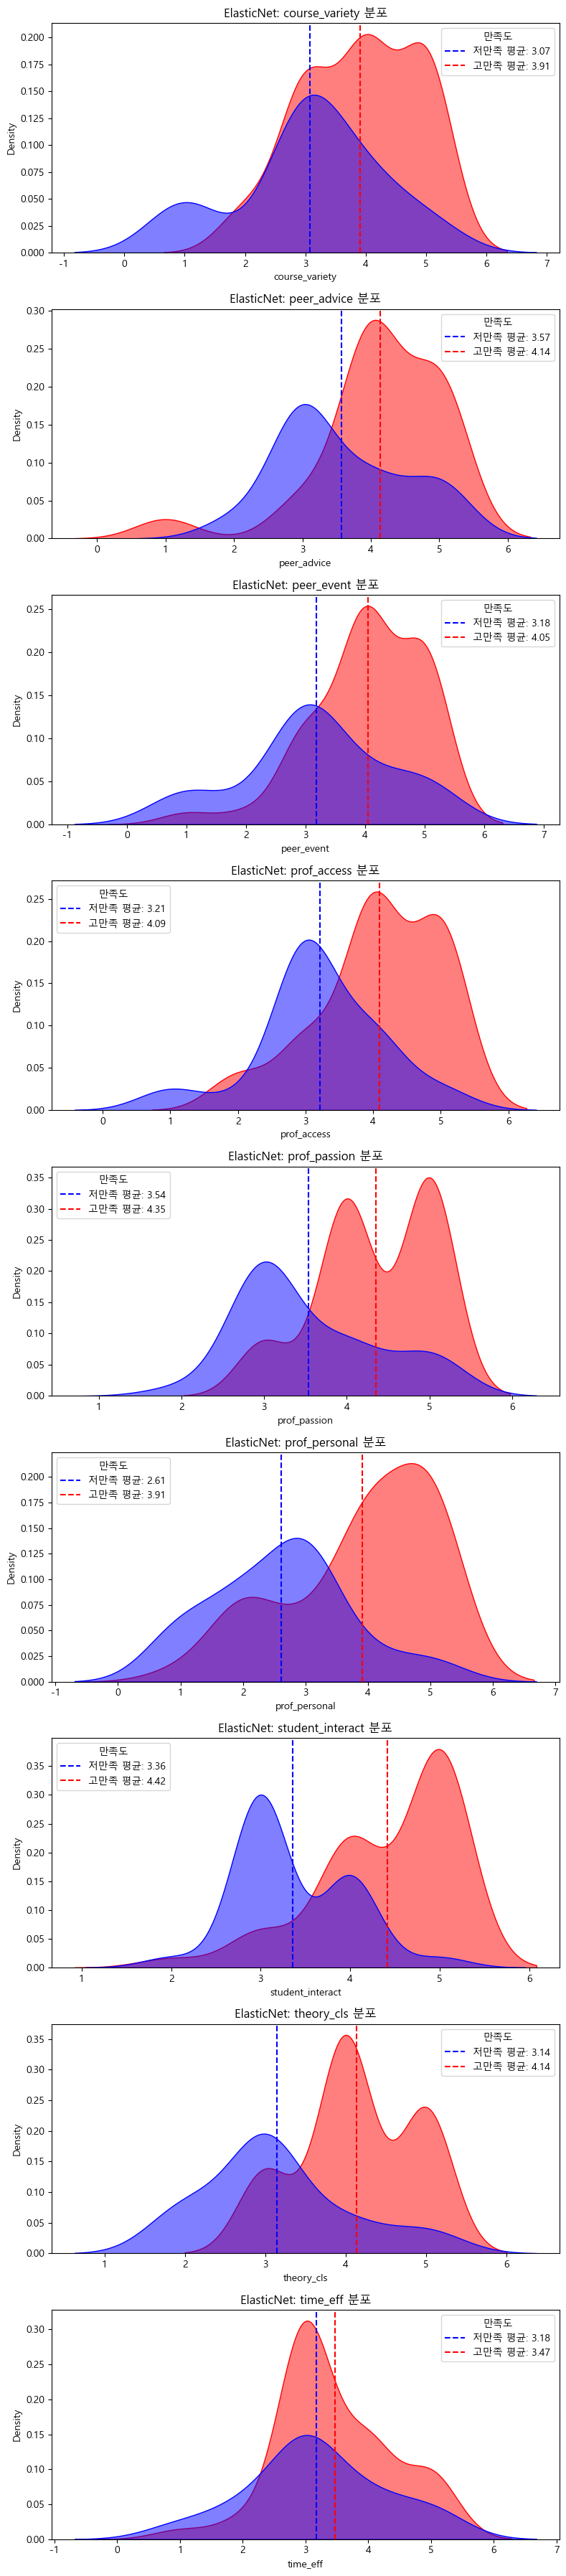

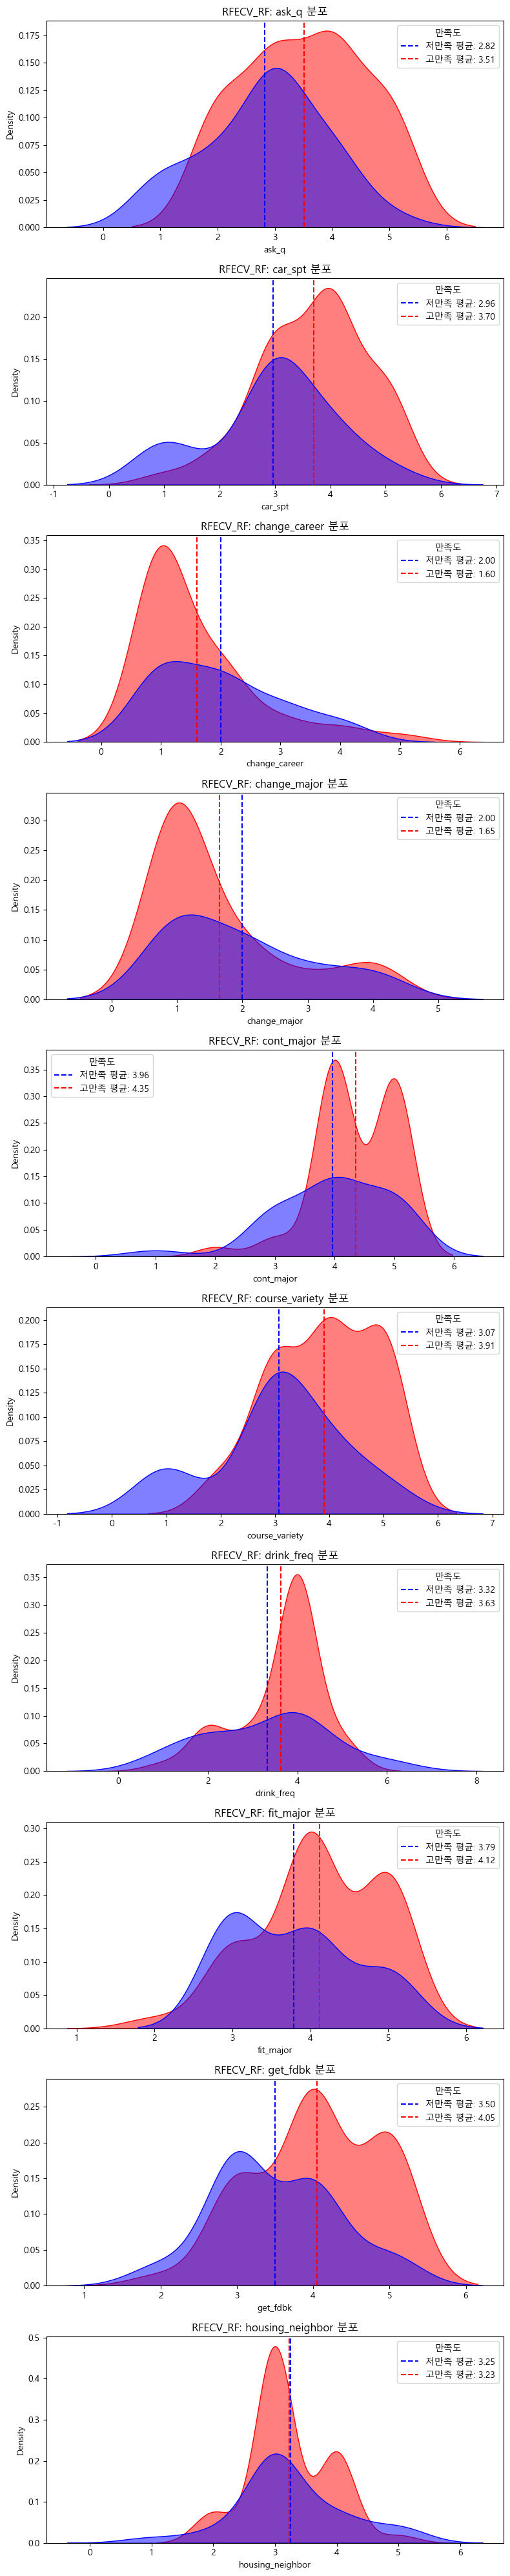

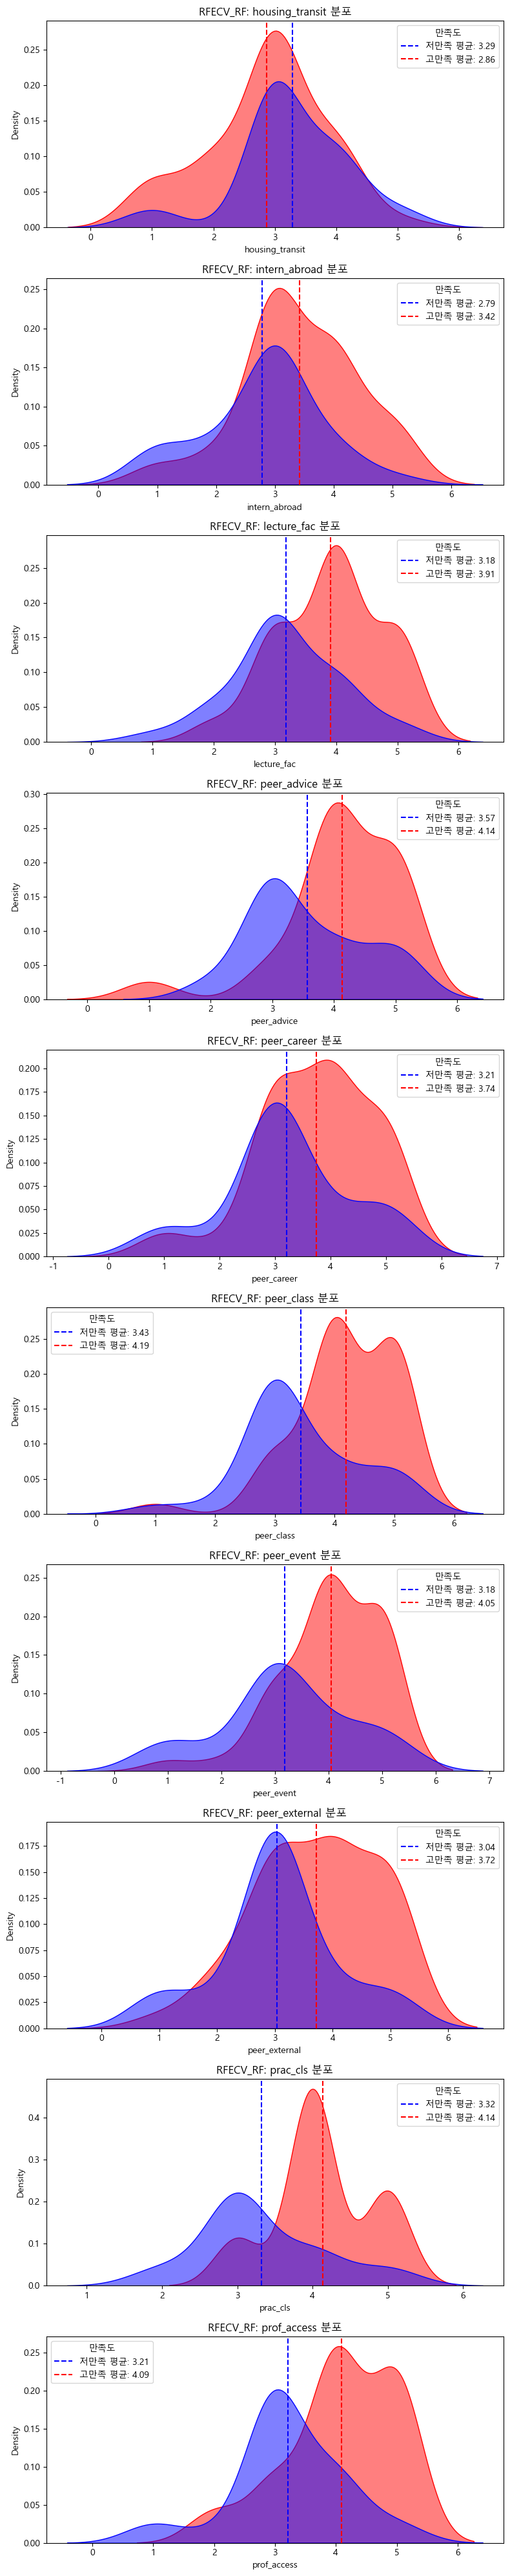

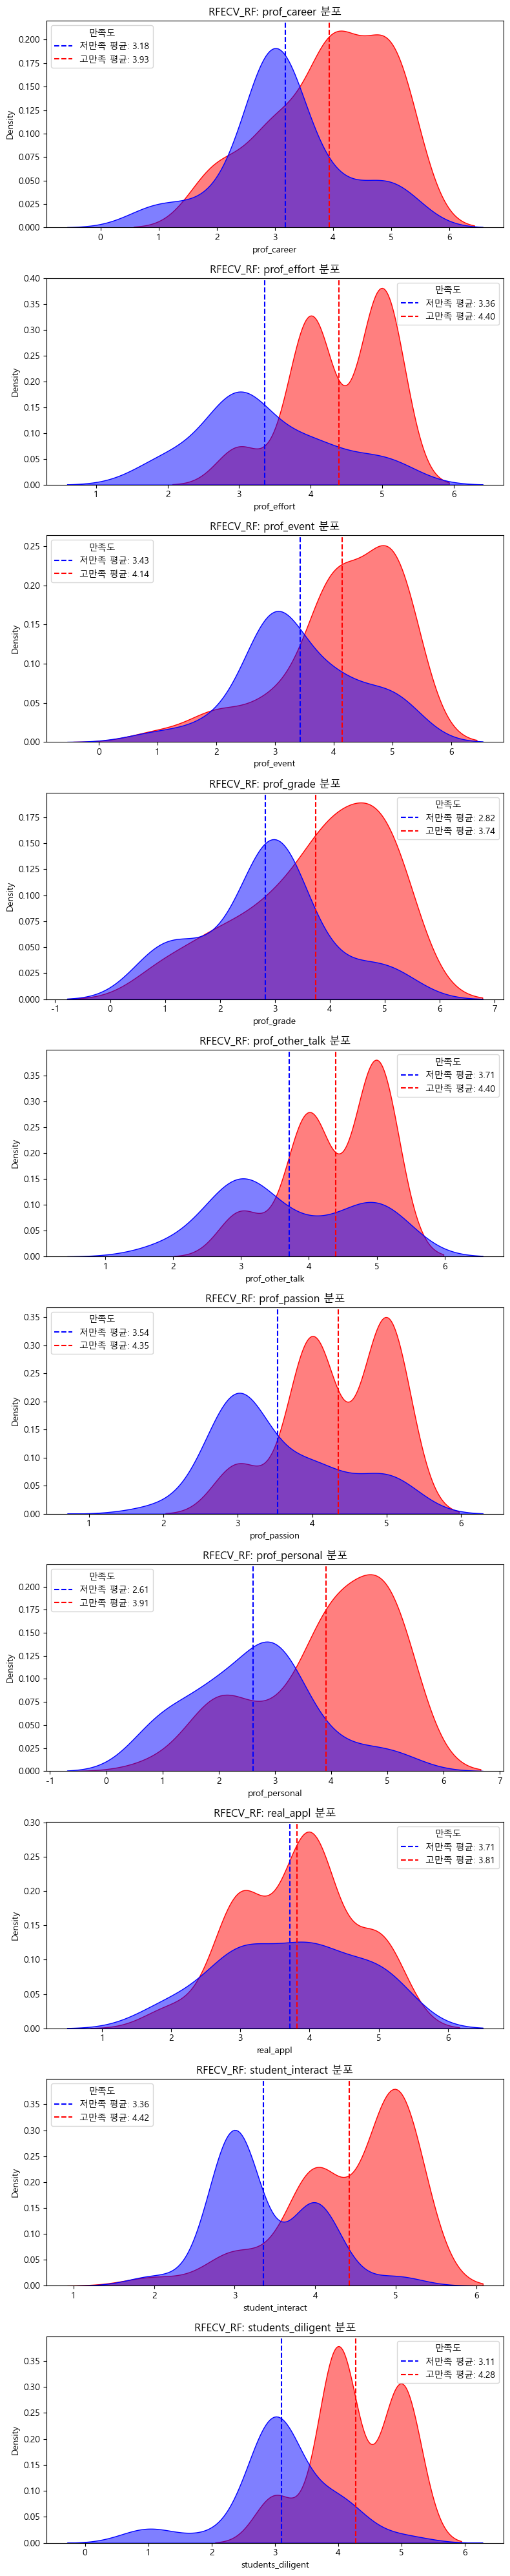

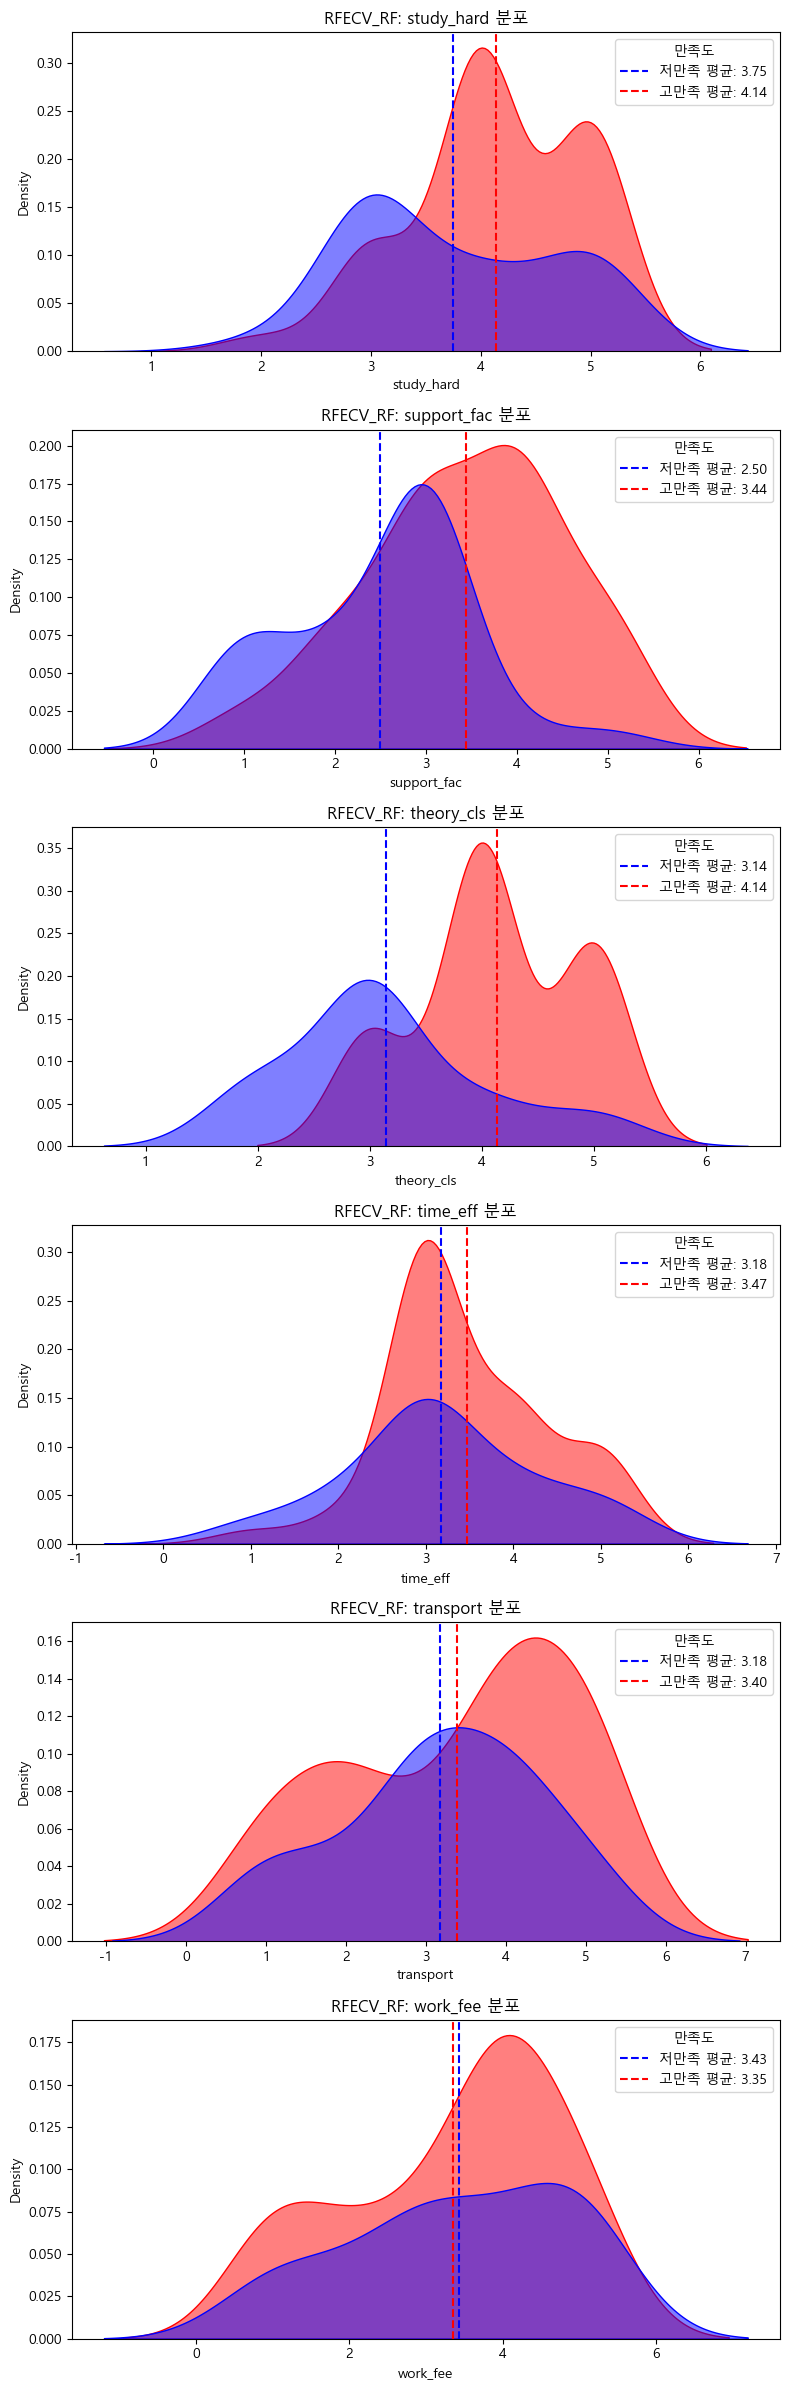

In [17]:
import matplotlib.pyplot as plt
import matplotlib

# 한글 폰트 설정 (Windows)
matplotlib.rcParams['font.family'] = 'Malgun Gothic'

# 음수 기호 깨짐 방지
matplotlib.rcParams['axes.unicode_minus'] = False


import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# 변수별 KDE: 고만족 vs 저만족
# -------------------------
def plot_kde_by_group(X_df, y_series, title_prefix=""):
    vars_ = X_df.columns
    n_vars = len(vars_)
    
    # subplot으로 한 화면에 표시 (최대 10개 변수는 한 화면)
    max_per_fig = 10
    for start in range(0, n_vars, max_per_fig):
        end = min(start + max_per_fig, n_vars)
        vars_subset = vars_[start:end]
        
        fig, axes = plt.subplots(len(vars_subset), 1, figsize=(8, 4*len(vars_subset)))
        if len(vars_subset) == 1:
            axes = [axes]  # 1개일 때 리스트로 변환
            
        for i, var in enumerate(vars_subset):
            sns.kdeplot(
                data=X_df,
                x=var,
                hue=y_series,
                fill=True,
                common_norm=True,   # 그룹 간 비교 쉽게
                palette={0: "blue", 1: "red"},
                alpha=0.5,
                ax=axes[i]
            )
            
            # 평균값 표시
            mean_0 = X_df[y_series==0][var].mean()
            mean_1 = X_df[y_series==1][var].mean()
            axes[i].axvline(mean_0, color='blue', linestyle='--', label=f'저만족 평균: {mean_0:.2f}')
            axes[i].axvline(mean_1, color='red', linestyle='--', label=f'고만족 평균: {mean_1:.2f}')
            
            axes[i].set_title(f"{title_prefix}{var} 분포")
            axes[i].set_xlabel(var)
            axes[i].set_ylabel("Density")
            axes[i].legend(title="만족도")
        
        plt.tight_layout()
        plt.show()


# -------------------------
# ElasticNet 변수 KDE
# -------------------------
plot_kde_by_group(
    X_df = focus_models["ENet_XGB"]["X_test"], 
    y_series = focus_models["ENet_XGB"]["y_test"], 
    title_prefix="ElasticNet: "
)

# -------------------------
# RFECV_RF 변수 KDE
# -------------------------
plot_kde_by_group(
    X_df = focus_models["RFECV_RF"]["X_test"], 
    y_series = focus_models["RFECV_RF"]["y_test"], 
    title_prefix="RFECV_RF: "
)





===== ElasticNet 변수 세트: 상관관계 분석 =====


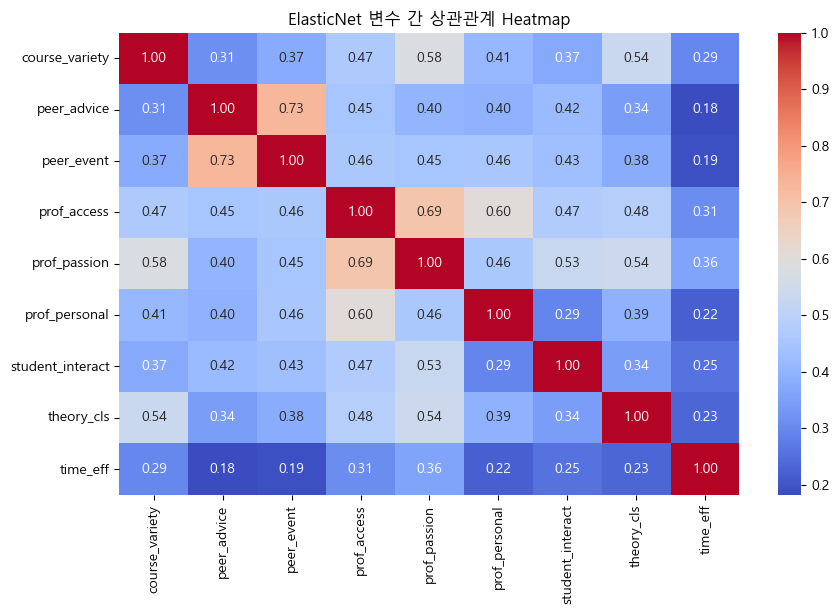


ElasticNet VIF 지수:


,feature,VIF
4,prof_passion,64.871237
3,prof_access,44.442570
1,peer_advice,33.222658
6,student_interact,31.607171
2,peer_event,31.376062
7,theory_cls,23.444616
0,course_variety,19.450819
8,time_eff,15.442712
5,prof_personal,14.766452




===== RFECV_RF 변수 세트: 상관관계 분석 =====


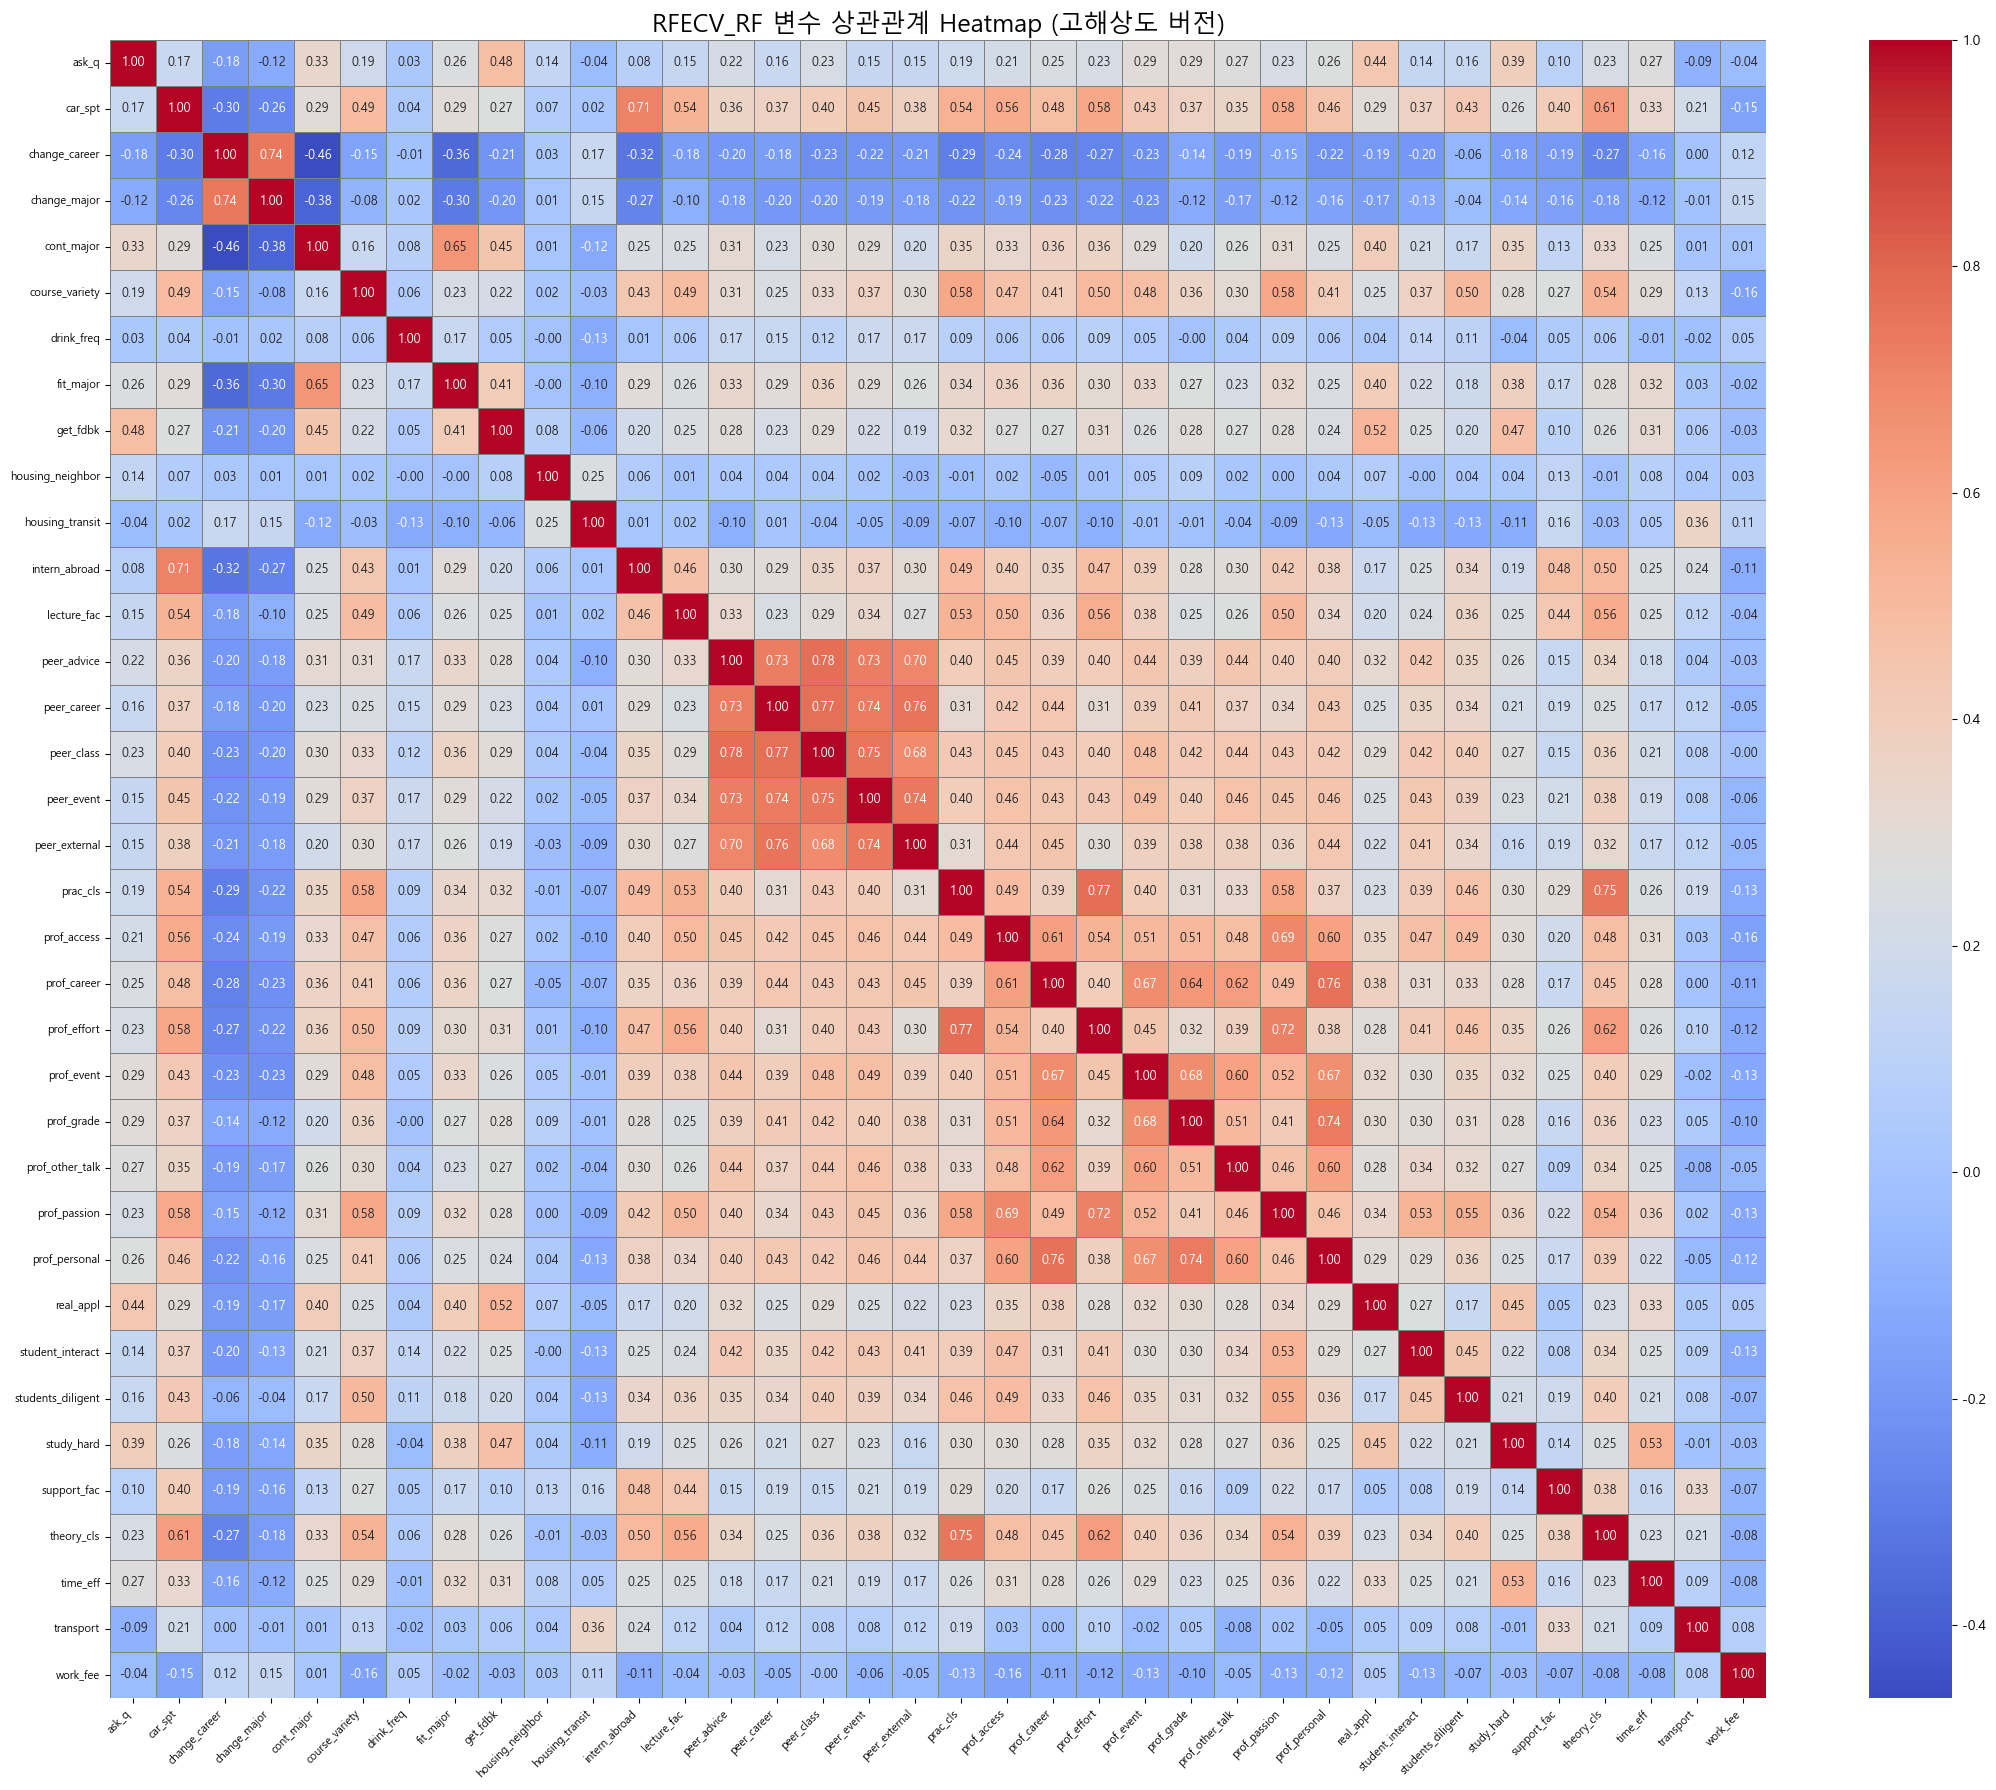

In [19]:
# ==========================================
# 📌 ENet / RFECV_RF 변수 세트: 상관관계 + VIF 분석
# ==========================================

import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# -------------------------
# VIF 계산 함수
# -------------------------
def compute_vif(df):
    vif_data = pd.DataFrame()
    vif_data["feature"] = df.columns
    vif_data["VIF"] = [
        variance_inflation_factor(df.values, i) for i in range(df.shape[1])
    ]
    return vif_data.sort_values("VIF", ascending=False)


# -------------------------
# 📌 1) ElasticNet 변수 세트
# -------------------------
print("\n\n===== ElasticNet 변수 세트: 상관관계 분석 =====")

X_enet_corr = df[elasticnet_vars]

# 🔹 상관관계 Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(X_enet_corr.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("ElasticNet 변수 간 상관관계 Heatmap")
plt.show()

# 🔹 VIF 지수
enet_vif = compute_vif(X_enet_corr)
print("\nElasticNet VIF 지수:")
display(enet_vif)



# -------------------------
# 📌 2) RFECV_RF 변수 세트
# -------------------------
print("\n\n===== RFECV_RF 변수 세트: 상관관계 분석 =====")

X_rf_corr = df[rfecv_rf_vars]

plt.figure(figsize=(22, 18))  # 🔥 훨씬 큰 크기
corr = df[rfecv_rf_vars].corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True,        # 🔥 숫자 표시
    fmt=".2f",         # 🔥 소수 2자리
    annot_kws={"size": 9},  # 🔥 수치 글씨 크기
    linewidths=0.5,    # 🔥 셀 구분선 추가 (더 선명)
    linecolor="gray"
)

plt.title("RFECV_RF 변수 상관관계 Heatmap (고해상도 버전)", fontsize=18)

plt.xticks(fontsize=8, rotation=45, ha="right")  # 🔥 X축 글씨 개선
plt.yticks(fontsize=8)

plt.tight_layout()  # 🔥 글씨 겹침 방지
plt.show()
